# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [25]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [ ]:
# extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'
zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

# list CSV files under EXTRACT_DIR
csv_path = "heart_ds/dataset_heart.csv"  # set to the CSV you choose

# load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# TODO: inspect df
print(df.head())
print()
print(df.info())
print()
print(df["heart disease"].value_counts())

# identify target column
target = "heart disease"

# split features and target
X = df.drop(columns=target)
# map to binary
y = df[target].map({1: 0, 2: 1})   # 0 = no disease, 1 = disease


# train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y)


   age  sex   chest pain type  resting blood pressure  serum cholestoral  \
0   70     1                4                     130                322   
1   67     0                3                     115                564   
2   57     1                2                     124                261   
3   64     1                4                     128                263   
4   74     0                2                     120                269   

   fasting blood sugar  resting electrocardiographic results  max heart rate  \
0                    0                                     2             109   
1                    0                                     2             160   
2                    0                                     0             141   
3                    0                                     0             105   
4                    0                                     2             121   

   exercise induced angina  oldpeak  ST segment  major vessels

### Basic visual checks

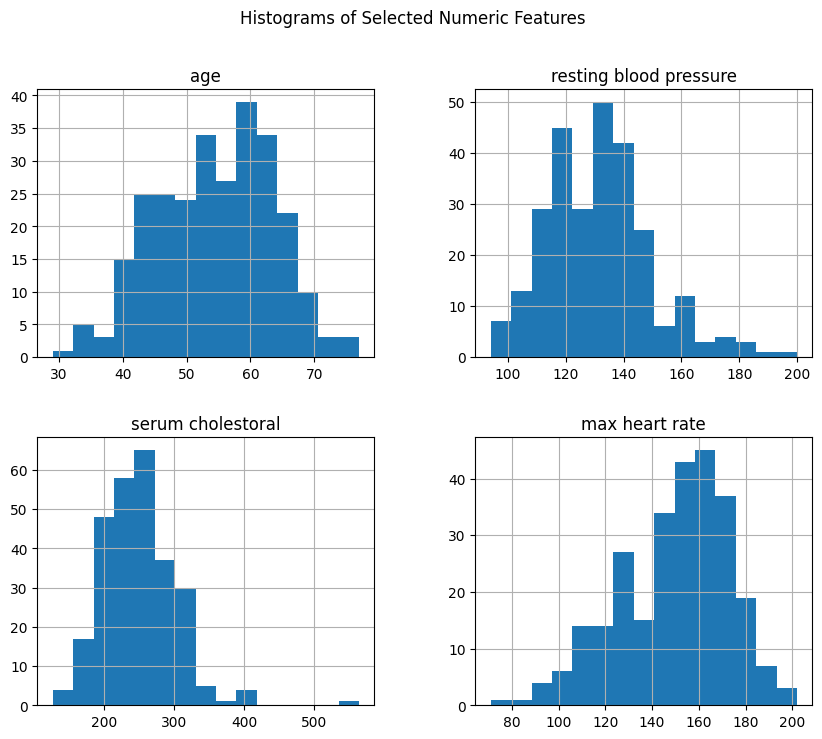

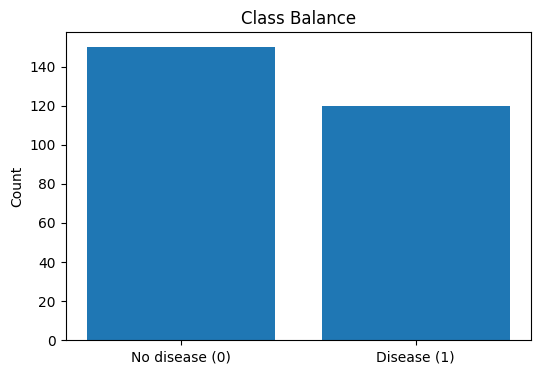

In [27]:
# TODO: pick a few numeric columns and plot histograms
num_cols = ["age", "resting blood pressure", "serum cholestoral", "max heart rate"]

df[num_cols].hist(figsize=(10,8), bins=15)
plt.suptitle("Histograms of Selected Numeric Features")
plt.show()

# plot class balance as a bar chart
class_counts = y.value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["No disease (0)", "Disease (1)"], class_counts.values)
plt.ylabel("Count")
plt.title("Class Balance")
plt.show()



## Preprocessing pipeline

In [28]:
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

## Helper - evaluation function

In [29]:
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # predictions
    y_pred = model.predict(X_test)

    # compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }
    print(name, metrics)

    # confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.colorbar()
    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["True 0", "True 1"])
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    # write numbers inside the boxes
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.show()

    # ROC curve if model has predict_proba
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{name} - ROC Curve")
        plt.legend()
        plt.show()

        metrics["roc_auc"] = auc

    return metrics


## Exercise 2 - Logistic Regression without Grid Search

Logistic Regression {'accuracy': 0.8518518518518519, 'precision': 0.7857142857142857, 'recall': 0.9166666666666666, 'f1': 0.8461538461538461}


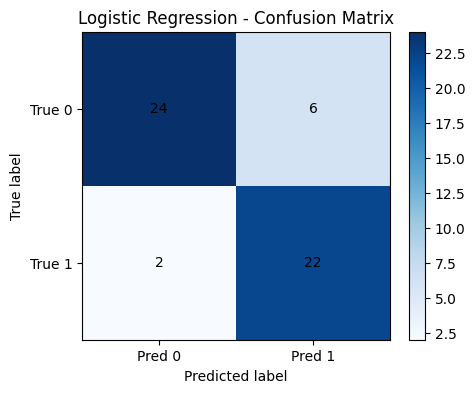

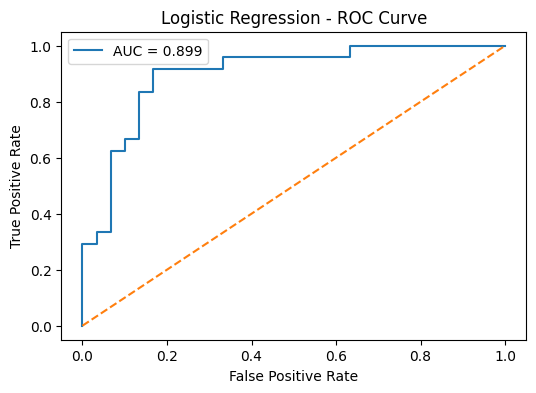

In [30]:
# create a Pipeline with your preprocessor and LogisticRegression
pipe_lr = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE))
])

# fit on training data
pipe_lr.fit(X_train, y_train)

# evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report("Logistic Regression", pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}
LR grid {'accuracy': 0.8518518518518519, 'precision': 0.7857142857142857, 'recall': 0.9166666666666666, 'f1': 0.8461538461538461}


/opt/miniconda3/envs/di-genai/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/di-genai/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/miniconda3/envs/di-genai/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', 

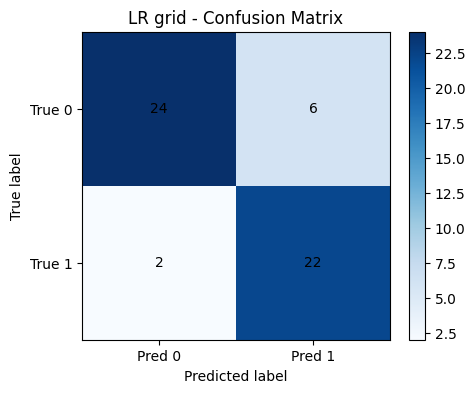

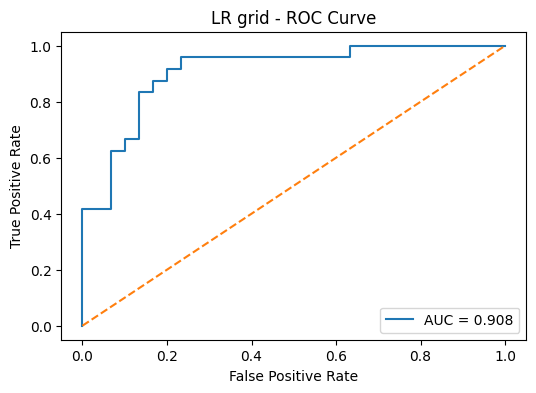

In [31]:
# build a Pipeline same as above
pipe_lr_cv = Pipeline([
    ("pre", pre),
    ("lr", LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE))
])

# define param_grid for lr__C and lr__penalty
param_grid = {
    "lr__C": [0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l1", "l2"],
}

# GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(
    estimator=pipe_lr_cv,
    param_grid=param_grid,
    cv=5,
    scoring="f1"
)

grid_lr.fit(X_train, y_train)
print("Best params:", grid_lr.best_params_)

best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report("LR grid", best_lr, X_test, y_test)


## Exercise 4 - SVM without Grid Search

SVM no grid {'accuracy': 0.8148148148148148, 'precision': 0.7692307692307693, 'recall': 0.8333333333333334, 'f1': 0.8}


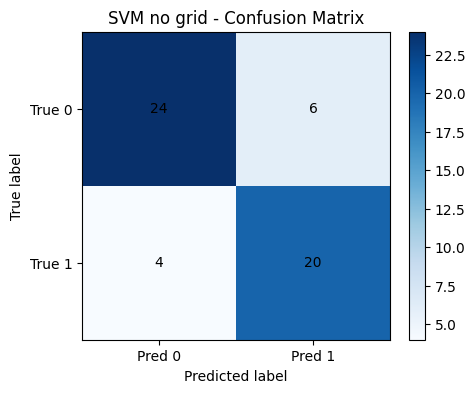

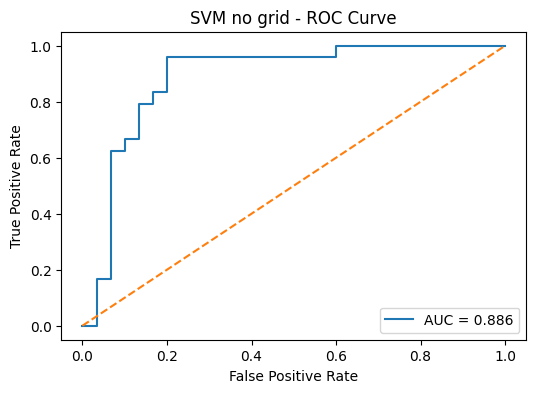

In [32]:
# choose kernel and hyperparameters for SVC
pipe_svm = Pipeline([
    ("pre", pre),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE))
])

pipe_svm.fit(X_train, y_train)

svm_no_metrics = eval_and_report("SVM no grid", pipe_svm, X_test, y_test)


## Exercise 5 - SVM with Grid Search

In [33]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = None

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    # 'svm__kernel': ['rbf','linear'],
    # 'svm__C': [...],
    # 'svm__gamma': ['scale','auto', ...],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = None
# best_svm = grid_svm.best_estimator_
# svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)


## Exercise 6 - XGBoost without Grid Search

Best SVM params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
SVM grid {'accuracy': 0.8518518518518519, 'precision': 0.8076923076923077, 'recall': 0.875, 'f1': 0.84}


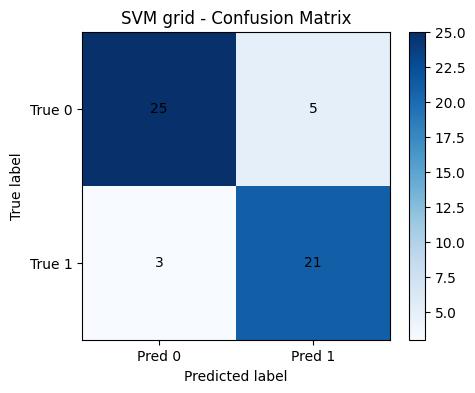

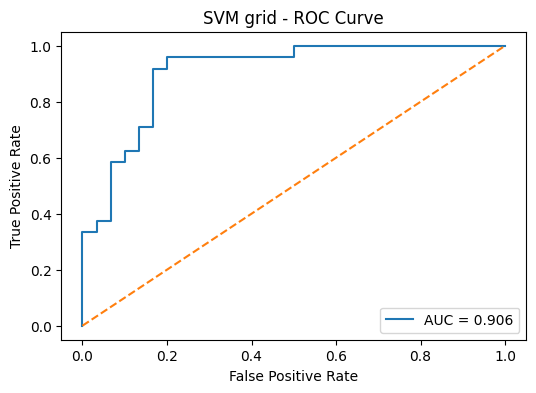

In [34]:
# Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline([
    ("pre", pre),
    ("svm", SVC(probability=True, random_state=RANDOM_STATE))
])

# param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    "svm__kernel": ["rbf", "linear"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto"]
}

# GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(
    estimator=pipe_svm_cv,
    param_grid=svm_param_grid,
    cv=5,
    scoring="f1"
)

grid_svm.fit(X_train, y_train)
print("Best SVM params:", grid_svm.best_params_)

best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report("SVM grid", best_svm, X_test, y_test)


## Exercise 7 - XGBoost with Grid Search

Best XGB params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.2, 'xgb__max_depth': 5, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}
XGB grid {'accuracy': 0.8333333333333334, 'precision': 0.8, 'recall': 0.8333333333333334, 'f1': 0.8163265306122449}


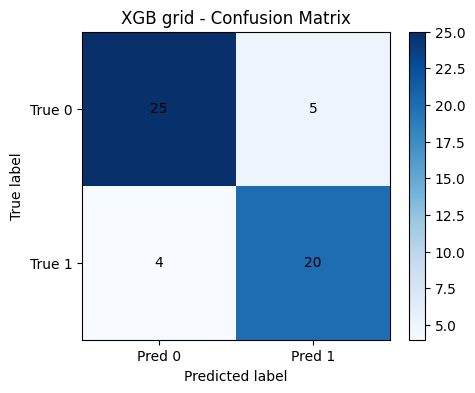

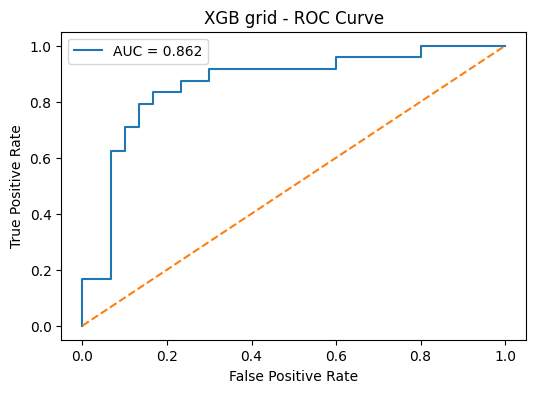

In [35]:
# Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline([
    ("pre", pre),
    ("xgb", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ))
])

# define a reasonable param_grid
xgb_param_grid = {
    "xgb__n_estimators": [50, 100, 200],
    "xgb__learning_rate": [0.01, 0.1, 0.2],
    "xgb__max_depth": [3, 4, 5],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
}

# GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(
    estimator=pipe_xgb_cv,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="f1"
)

grid_xgb.fit(X_train, y_train)
print("Best XGB params:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report("XGB grid", best_xgb, X_test, y_test)


## Compare models

In [38]:
summary = {}

summary["LR no grid"] = lr_no_gs_metrics
summary["LR grid"] = lr_gs_metrics
summary["SVM no grid"] = svm_no_metrics
summary["SVM grid"] = svm_gs_metrics

# only if XGBoost ran successfully
if "xgb_gs_metrics" in globals():
    summary["XGB grid"] = xgb_gs_metrics

summary_df = pd.DataFrame.from_dict(summary, orient="index")

summary_df.round(3)


,accuracy,precision,recall,f1,roc_auc
LR no grid,0.852,0.786,0.917,0.846,0.899
LR grid,0.852,0.786,0.917,0.846,0.908
SVM no grid,0.815,0.769,0.833,0.800,0.886
SVM grid,0.852,0.808,0.875,0.840,0.906
XGB grid,0.833,0.800,0.833,0.816,0.862


Several classification models were evaluated for heart disease prediction, including Logistic Regression, Support Vector Machines (SVM), and XGBoost. Performance was measured using accuracy, precision, recall, F1-score, and ROC-AUC.

Logistic Regression achieved the strongest overall performance, with an accuracy of 0.852, recall of 0.917, and F1-score of 0.846. Grid search tuning did not change the main metrics but slightly improved the ROC-AUC score from 0.899 to 0.908, indicating a marginal improvement in the model’s ability to separate the classes.

The SVM model initially performed worse (F1 = 0.800), but hyperparameter tuning improved its performance significantly, raising the F1-score to 0.840 and ROC-AUC to 0.906, bringing it close to Logistic Regression.

The XGBoost model performed reasonably well but slightly worse than the tuned Logistic Regression and SVM models, with an F1-score of 0.816 and ROC-AUC of 0.862.

Overall, Logistic Regression with grid search provided the best balance between recall and precision, making it the most effective model for this dataset. The high recall (0.917) suggests the model successfully identifies most cases of heart disease, which is especially important in a medical prediction context.